# Phase 5: Neural Style Transfer Engine
This is the grand finale. We are going to initialize the AI, hand it Conor McGregor as the Content Target, hand it the Icarus painting as the Style Target, and let it optimize for 300 steps!

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from data.image_loader import load_image, tensor_to_image
from models.neural_style_transfer import StyleTransferEngine

In [2]:
# 1. Setup the GPU and Engine
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
engine = StyleTransferEngine(device)

# 2. Load the Inputs
content_img = load_image('../data/content_images/mcgregor.jpg', max_size=400).to(device)
style_img = load_image('../data/style_images/icarus.jpg', max_size=400).to(device)

print("Engine and Images loaded!")

Engine and Images loaded!


In [3]:
# 3. Run the Magic!
# Note: L-BFGS takes longer per step than basic Adam, but it converges much more beautifully.
# This cell might take a few minutes to run depending on your CPU/GPU.

final_image_tensor = engine.run(
    content_img=content_img, 
    style_img=style_img, 
    num_steps=300, 
    style_weight=1000000, 
    content_weight=1
)

Extracting targets (The answers to the test)...
Preparing the blank canvas...
Optimizing...
Step 50: Style Loss: 0.4473 Content Loss: 0.8515
Step 100: Style Loss: 0.3649 Content Loss: 0.7633
Step 150: Style Loss: 0.3359 Content Loss: 0.7281
Step 200: Style Loss: 0.3214 Content Loss: 0.7104
Step 250: Style Loss: 0.3132 Content Loss: 0.6975
Step 300: Style Loss: 0.3076 Content Loss: 0.6895
Step 350: Style Loss: 0.3036 Content Loss: 0.6840


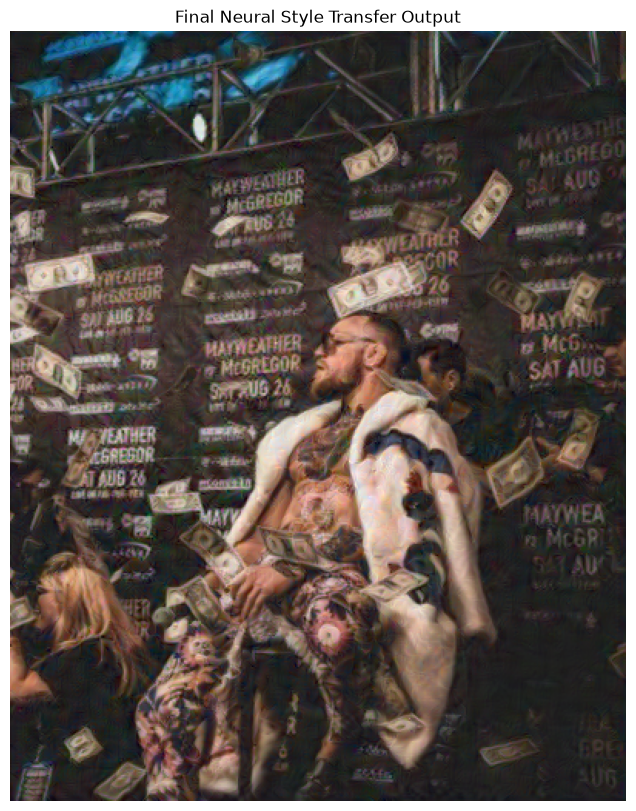

In [4]:
# 4. Display the Final Masterpiece
final_image = tensor_to_image(final_image_tensor)

plt.figure(figsize=(10, 10))
plt.imshow(final_image)
plt.axis('off')
plt.title('Final Neural Style Transfer Output')
plt.show()

In [5]:
# Optional: Save the masterpiece to disk
os.makedirs('../outputs', exist_ok=True)
final_image.save('../outputs/mcgregor_icarus.jpg')
print("Masterpiece saved to outputs folder!")

Masterpiece saved to outputs folder!
